In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.collections as mc
import seaborn as sns
import re
from scipy.stats import pearsonr

In [2]:
original_data = pd.read_csv("responses_32.csv")

In [3]:
# Function to create dictionary for renaming columns
def edit_cols(cols):
    nudge_num = 1
    risk_num = 1
    col_dict = {}
    for i, OLD_col in enumerate(cols):
        col = OLD_col.lower().strip()
        if col[0].isnumeric():
            first_word = col.split(" ")[1]
            if first_word == "select":
                NEW_col = "risk_" + str(risk_num)
                risk_num += 1
            elif first_word == "this":
                NEW_col = "nudge_" + str(nudge_num)
                nudge_num += 1
        elif "age" in col:
            NEW_col = "age"
        elif "parents" in col:
            NEW_col = "parent_edu"
        elif "income" in col:
            NEW_col = "income"
        elif col == "what do you think this survey was about?":
            NEW_col = "participant_bias"
        elif "questions" in col:
            NEW_col = "comments"
        else:
            NEW_col = col
        
        col_dict[OLD_col] = NEW_col
    
    return col_dict

In [81]:
# Create dictionary for column name mapping; rename columns
col_dict = edit_cols(original_data.columns)
data = original_data.rename(columns=col_dict)

# Basic data cleaning
data = data.map(lambda x: x.strip()[-1] if "option" in str(x).lower() else x)

gender_dict = {"Man": "M", "Woman": "W", "Non-binary": "NB"}
data['gender'] = data['gender'].map(gender_dict)

data.replace({"Grad Student": "Graduate", "I'm not a student": "Non-Student", "Prefer not to specify": "Decline"}, inplace=True)

for col in data.columns:
    if "nudge" in col:
        data[col] = data[col].map(lambda x: x if x == "B" else "none")

data['participant'] = ["P" + str(val) for val in np.arange(len(data)) + 1]

In [5]:
data.head()

,timestamp,gender,year,age,parent_edu,income,risk_1,risk_2,nudge_1,nudge_2,...,nudge_6,nudge_7,risk_9,nudge_8,risk_10,nudge_9,nudge_10,participant_bias,comments,participant
0,2/28/2026 20:38:36,M,Senior,22-25,Masters or professional degree,PNTS,A,A,none,none,...,none,none,A,none,A,none,none,Your family background and its implication on...,Cool stuff,P1
1,2/28/2026 20:44:12,M,Junior,18-21,Masters or professional degree,"$250,000+",A,A,none,none,...,B,B,A,B,B,B,B,A supposed correlation between financial choic...,I have OCD,P2
2,2/28/2026 20:44:32,M,Senior,22-25,Undergraduate degree,"$100,000-200,000",B,B,B,B,...,B,none,B,B,B,none,B,s,NaN,P3
3,3/1/2026 12:56:50,W,Junior,18-21,Masters or professional degree,"$250,000+",B,B,B,B,...,B,none,A,none,B,none,B,Risk tolerance,Too many qs; wasn’t thinking as critically at ...,P4
4,3/1/2026 13:02:04,W,Freshman,18-21,Undergraduate degree,"$100,000-200,000",B,B,B,B,...,B,none,B,B,A,B,none,.,NaN,P5


In [6]:
# Create DataFrame to store question information
questions_df = pd.DataFrame(index = [col for col in data.columns if "risk" in col or "nudge" in col])

# Extract and store the opetions for each question
for key, val in col_dict.items():
    if "risk" in val or "nudge" in val:
        for i in key.strip().split("\n"):
            if "option a" in i.lower():
                questions_df.loc[val, 'Option_A'] = i.split(":")[-1].strip()
            elif "option b" in i.lower():
                questions_df.loc[val, 'Option_B'] = i.split(":")[-1].strip()

# Indicate whic option is riskier (manually determined) 
risky_choice = np.array(["A", "A", "A", "A", "B", "B", "B", "B", "A", "B", "B", "NaN", "A", "A", "NaN", "A", "A", "A", "A", "A"])
questions_df['risky_choice'] = risky_choice

# Indicate direction of nudge (if applicable)
for question in questions_df.index:
    if "nudge" in question:
        if questions_df.loc[question, 'risky_choice'] == "A":
            questions_df.loc[question, 'nudge_direction'] = "to_risky"
        else:
            questions_df.loc[question, 'nudge_direction'] = "to_safe"
    else:   
        questions_df.loc[question, 'nudge_direction'] = "none"

In [7]:
questions_df

,Option_A,Option_B,risky_choice,nudge_direction
risk_1,"40% chance of $300, 60% chance of nothing.",100% chance of $110,A,none
risk_2,"40% chance of $200, 60% chance of nothing.",100% chance of $80,A,none
nudge_1,"40% chance of $300, 60% chance of nothing.",100% chance of $110,A,to_risky
nudge_2,"40% chance of $200, 60% chance of nothing.",100% chance of $80,A,to_risky
risk_3,100% chance of $50,"50% chance of $100, 50% chance of nothing",B,none
nudge_3,100% chance of $50,"50% chance of $100, 50% chance of nothing",B,to_safe
risk_4,100% chance of $20,"50% chance of $45, 50% chance of nothing",B,none
risk_5,100% chance of $220,"50% chance of $400, 50% chance of $40",B,none
risk_6,"25% chance of $800, 75% chance of $100",100% chance of $310,A,none
nudge_4,100% chance of $20,"50% chance of $45, 50% chance of nothing",B,to_safe


In [8]:
def format_outcomes(col):
    choices = []
    for choice in questions_df[col]:
        outcome_list = choice.split(",")
        outcomes = []
        for outcome in outcome_list:
            outcome = re.sub(r'[^\w\s%$]', "", outcome)
            outcome = outcome.strip().split(" ")
            formatted_outcome = []
            for item in outcome:
                if item.endswith("%"):
                    p = item.strip("%")
                    p = float(p) / 100
                    formatted_outcome.append(p)
                elif item.startswith("$"):
                    v = item.strip("$")
                    v = float(v)
                    formatted_outcome.append(v)

            if len(formatted_outcome) != 2:
                formatted_outcome.append(0)
            outcomes.append(formatted_outcome)
        choices.append(outcomes)
    return choices


In [9]:
questions_df["outcomes_A"] = format_outcomes("Option_A")
questions_df["outcomes_B"] = format_outcomes("Option_B")

In [10]:
shannon_entropy = lambda x: x * np.log2(x) if x > 0 else 0

def calculate_entropy(col):
    entropy_col = []
    for outcomes in questions_df[col]:
        p_list = []
        for outcome in outcomes:
            p_list.append(outcome[0])
        shannon = map(shannon_entropy, p_list)
        entropy_sum = -1 * sum(shannon)
        entropy_col.append(entropy_sum)
    return entropy_col

questions_df["entropy_A"] = calculate_entropy("outcomes_A")
questions_df["entropy_B"] = calculate_entropy("outcomes_B")

In [11]:
questions_df

,Option_A,Option_B,risky_choice,nudge_direction,outcomes_A,outcomes_B,entropy_A,entropy_B
risk_1,"40% chance of $300, 60% chance of nothing.",100% chance of $110,A,none,"[[0.4, 300.0], [0.6, 0]]","[[1.0, 110.0]]",0.970951,-0.000000
risk_2,"40% chance of $200, 60% chance of nothing.",100% chance of $80,A,none,"[[0.4, 200.0], [0.6, 0]]","[[1.0, 80.0]]",0.970951,-0.000000
nudge_1,"40% chance of $300, 60% chance of nothing.",100% chance of $110,A,to_risky,"[[0.4, 300.0], [0.6, 0]]","[[1.0, 110.0]]",0.970951,-0.000000
nudge_2,"40% chance of $200, 60% chance of nothing.",100% chance of $80,A,to_risky,"[[0.4, 200.0], [0.6, 0]]","[[1.0, 80.0]]",0.970951,-0.000000
risk_3,100% chance of $50,"50% chance of $100, 50% chance of nothing",B,none,"[[1.0, 50.0]]","[[0.5, 100.0], [0.5, 0]]",-0.000000,1.000000
nudge_3,100% chance of $50,"50% chance of $100, 50% chance of nothing",B,to_safe,"[[1.0, 50.0]]","[[0.5, 100.0], [0.5, 0]]",-0.000000,1.000000
risk_4,100% chance of $20,"50% chance of $45, 50% chance of nothing",B,none,"[[1.0, 20.0]]","[[0.5, 45.0], [0.5, 0]]",-0.000000,1.000000
risk_5,100% chance of $220,"50% chance of $400, 50% chance of $40",B,none,"[[1.0, 220.0]]","[[0.5, 400.0], [0.5, 40.0]]",-0.000000,1.000000
risk_6,"25% chance of $800, 75% chance of $100",100% chance of $310,A,none,"[[0.25, 800.0], [0.75, 100.0]]","[[1.0, 310.0]]",0.811278,-0.000000
nudge_4,100% chance of $20,"50% chance of $45, 50% chance of nothing",B,to_safe,"[[1.0, 20.0]]","[[0.5, 45.0], [0.5, 0]]",-0.000000,1.000000


In [12]:
# Keep in case, but this shis is useless for now
df = questions_df.copy().reset_index()
for i, (entropy_A, entropy_B) in enumerate(zip(df['entropy_A'], df['entropy_B'])):
    if entropy_A == entropy_B:
        outcomes_A = np.array(df.loc[i, "outcomes_A"])
        outcomes_B = np.array(df.loc[i, "outcomes_B"])

        idx_A = outcomes_A.flatten().argmax() // 2
        idx_B = outcomes_B.flatten().argmax() // 2

        max_A = shannon_entropy(outcomes_A[idx_A][0])
        max_B = shannon_entropy(outcomes_B[idx_B][0])
        
        df.at[i, 'entropy_A'] = max_A
        df.at[i, 'entropy_B'] = max_B
    else:
        continue

In [13]:
# Create DataFrame to store participant response classes to risk and nudge questions
risk_df = data[questions_df.index.to_list() + ["participant"]].copy()

# Classify participant responses as "R" (risky) or "S" (safe); add nudge acceptance column for nudge questions (1 for acceptance, 0 for rejection)
for col in risk_df.columns:
    if col != "participant":
        risky_choice = questions_df.loc[col, 'risky_choice']
        if "risk" in col:
            risk_df.loc[:, col] = risk_df[col].map(lambda x: "R" if x == risky_choice else "S")
        elif "nudge" in col:
            risk_df.loc[:, f"{col}_accept"] = risk_df[col].map(lambda x: 1 if x == 'none' else 0)
            risk_df.loc[:, col] = risk_df[col].map(lambda x: x if x == "B" else "A").map(lambda x: "R" if x == risky_choice else "S")

risk_df["pure_risk_preference"] = risk_df[[col for col in risk_df.columns if "risk" in col]].apply(lambda x: sum(x == "R")/10, axis=1)
risk_df["nudge_susceptibility"] = risk_df[[col for col in risk_df.columns if "nudge" in col and "accept" in col]].apply(lambda x: sum(x == 1)/10, axis=1)


# risk_df["nudge_susceptibility_to_risk"] = risk_df[[col for col in risk_df.columns if ]]

In [14]:
to_risky = questions_df[questions_df['nudge_direction'] == "to_risky"].index.to_list()
to_risky

['nudge_1', 'nudge_2', 'nudge_6', 'nudge_8', 'nudge_9', 'nudge_10']

In [15]:
risk_df.head()

,risk_1,risk_2,nudge_1,nudge_2,risk_3,nudge_3,risk_4,risk_5,risk_6,nudge_4,...,nudge_3_accept,nudge_4_accept,nudge_5_accept,nudge_6_accept,nudge_7_accept,nudge_8_accept,nudge_9_accept,nudge_10_accept,pure_risk_preference,nudge_susceptibility
0,R,R,R,R,S,S,R,S,S,S,...,1,1,1,1,1,1,1,1,0.5,1.0
1,R,R,R,R,R,R,S,R,S,R,...,0,0,1,0,0,0,0,0,0.5,0.3
2,S,S,S,S,S,S,S,S,S,S,...,1,1,1,0,1,0,1,0,0.0,0.5
3,S,S,S,S,S,S,R,S,S,R,...,1,0,1,0,1,1,1,0,0.2,0.5
4,S,S,S,S,R,S,R,S,S,S,...,1,1,1,0,1,0,0,1,0.3,0.5


In [16]:
risk_df['pure_risk_preference'].describe()

count    32.000000
mean      0.256250
std       0.150134
min       0.000000
25%       0.200000
50%       0.200000
75%       0.300000
max       0.600000
Name: pure_risk_preference, dtype: float64

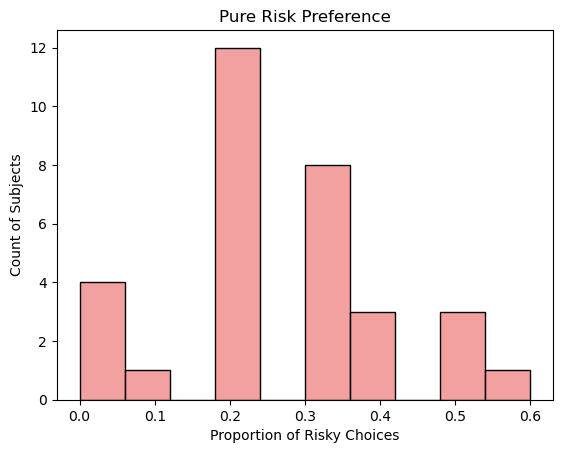

In [17]:
sns.histplot(risk_df['pure_risk_preference'], color='lightcoral')
plt.title('Pure Risk Preference')
plt.xlabel('Proportion of Risky Choices')
plt.ylabel('Count of Subjects')
plt.savefig('Pure Risk Preference.png', dpi=300, bbox_inches='tight')
plt.show()

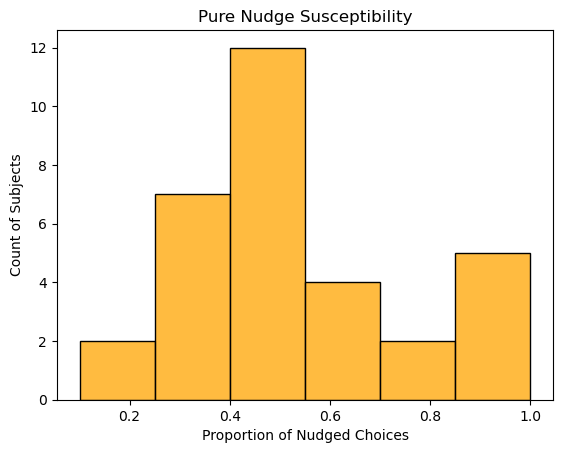

In [18]:
sns.histplot(risk_df['nudge_susceptibility'], color='orange')
plt.title('Pure Nudge Susceptibility')
plt.xlabel('Proportion of Nudged Choices')
plt.ylabel('Count of Subjects')
plt.savefig('Pure Nudge Susceptibility.png', dpi=300, bbox_inches='tight')
plt.show()

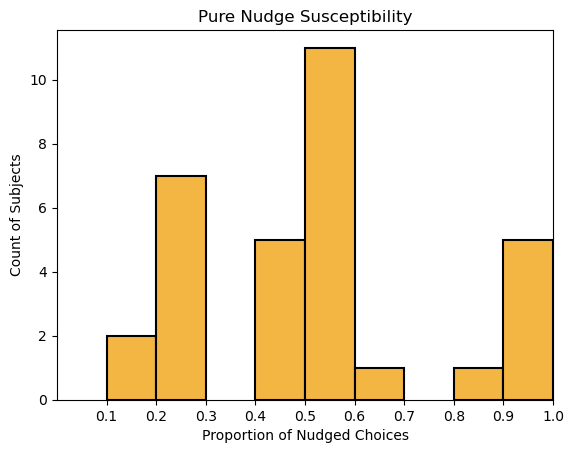

Participants with nudge susceptibility >= 0.66: 7


In [96]:
# histogram of nudge susceptibility with 0.1-wide bins
vals = risk_df["nudge_susceptibility"].dropna()

bins = np.arange(0, 1.01, 0.1)
counts, edges = np.histogram(vals, bins=bins)

centers = (edges[:-1] + edges[1:]) / 2
widths = np.diff(edges)

keep = counts > 0

fig, ax = plt.subplots()

ax.bar(
    centers[keep],
    counts[keep],
    width=widths[keep],
    color="#f4b642",
    edgecolor="black",
    linewidth=1.5
)

ax.set_title("Pure Nudge Susceptibility")
ax.set_xlabel("Proportion of Nudged Choices")
ax.set_ylabel("Count of Subjects")
ax.set_xticks(np.arange(0.1, 1.01, 0.1))
ax.set_xlim(0, 1.0)

plt.savefig("Pure Nudge Susceptibility.png", dpi=300, bbox_inches="tight")
plt.show()

# print how many participants were >= 0.66
n_high = (vals >= 0.66).sum()
print("Participants with nudge susceptibility >= 0.66:", n_high)

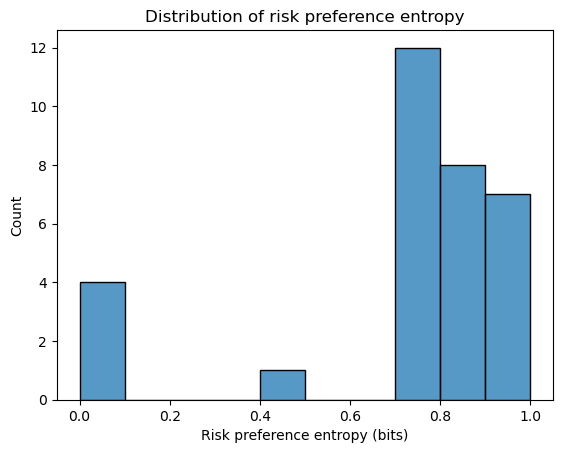

In [19]:
# participant-level Shannon entropy of risky vs safe choices
risk_df["risk_preference_entropy"] = risk_df["pure_risk_preference"].apply(
    lambda p: -(shannon_entropy(p) + shannon_entropy(1 - p))
)

sns.histplot(risk_df["risk_preference_entropy"], bins=10, kde=False, color='C0')
plt.xlabel("Risk preference entropy (bits)")
plt.ylabel("Count")
plt.title("Distribution of risk preference entropy")
plt.show()

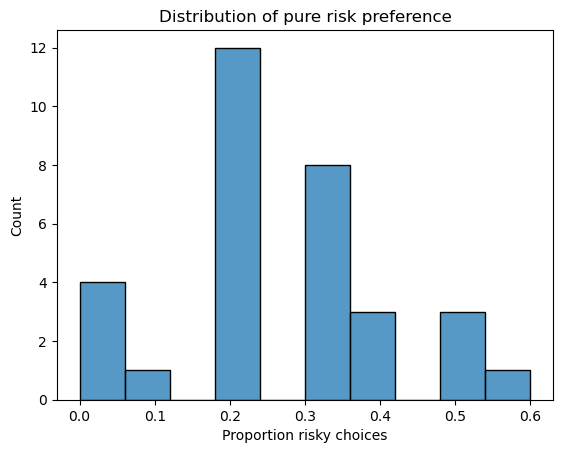

In [95]:
sns.histplot(risk_df["pure_risk_preference"], bins=10, kde=False, color='C0')
plt.xlabel("Proportion risky choices")
plt.ylabel("Count")
plt.title("Distribution of pure risk preference")
plt.show()

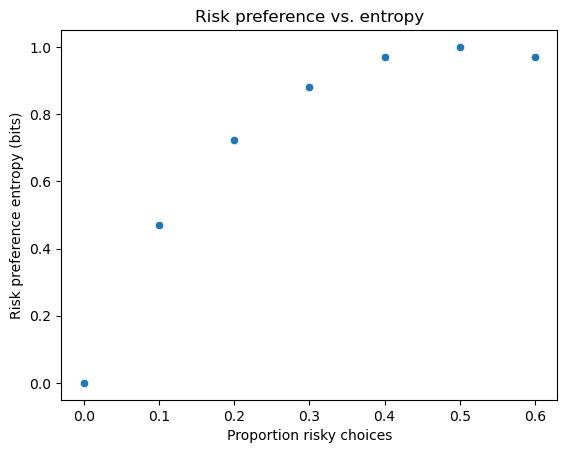

In [21]:
sns.scatterplot(data=risk_df, x="pure_risk_preference", y="risk_preference_entropy")
plt.xlabel("Proportion risky choices")
plt.ylabel("Risk preference entropy (bits)")
plt.title("Risk preference vs. entropy")
plt.show()

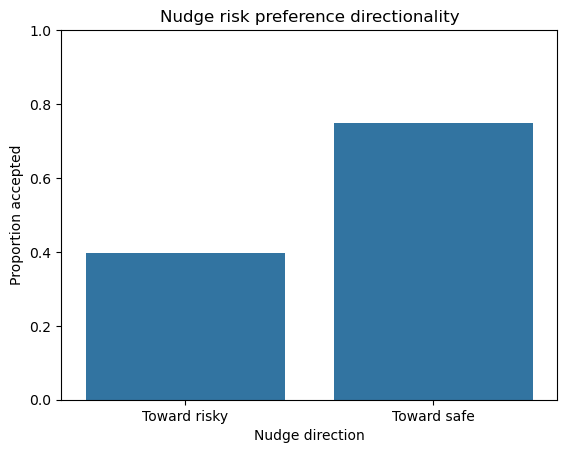

In [22]:
# keep only valid nudge questions, meaning we exclude ones where risky_choice was not coded
valid_nudges = questions_df[
    questions_df.index.str.contains("nudge") &
    questions_df["risky_choice"].isin(["A", "B"])
]

to_risky = valid_nudges[valid_nudges["nudge_direction"] == "to_risky"].index.to_list()
to_safe  = valid_nudges[valid_nudges["nudge_direction"] == "to_safe"].index.to_list()

# overall proportion of accepted nudges in each direction
plot_df = pd.DataFrame({
    "direction": ["Toward risky", "Toward safe"],
    "proportion_accepted": [
        risk_df[[f"{col}_accept" for col in to_risky]].to_numpy().mean(),
        risk_df[[f"{col}_accept" for col in to_safe]].to_numpy().mean()
    ]
})

sns.barplot(data=plot_df, x="direction", y="proportion_accepted", color="C0")
plt.ylim(0, 1)
plt.xlabel("Nudge direction")
plt.ylabel("Proportion accepted")
plt.title("Nudge risk preference directionality")
plt.savefig('Nudge risk preference directionality.png', dpi=300, bbox_inches='tight')
plt.show()

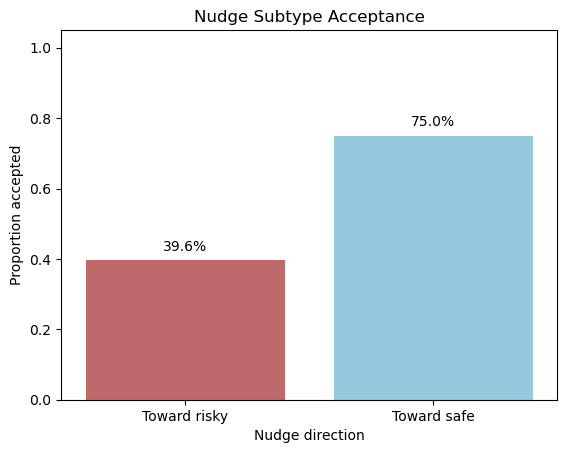

In [100]:
# keep only valid nudge questions, meaning we exclude ones where risky_choice was not coded
valid_nudges = questions_df[
    questions_df.index.str.contains("nudge") &
    questions_df["risky_choice"].isin(["A", "B"])
]

to_risky = valid_nudges[valid_nudges["nudge_direction"] == "to_risky"].index.to_list()
to_safe  = valid_nudges[valid_nudges["nudge_direction"] == "to_safe"].index.to_list()

# overall proportion of accepted nudges in each direction
plot_df = pd.DataFrame({
    "direction": ["Toward risky", "Toward safe"],
    "proportion_accepted": [
        risk_df[[f"{col}_accept" for col in to_risky]].to_numpy().mean(),
        risk_df[[f"{col}_accept" for col in to_safe]].to_numpy().mean()
    ]
})

palette = {"Toward risky": "indianred", "Toward safe": "skyblue"}

fig, ax = plt.subplots()

sns.barplot(
    data=plot_df,
    x="direction",
    y="proportion_accepted",
    hue="direction",
    palette=palette,
    dodge=False,
    legend=False,
    ax=ax
)

# add percent labels on top of bars
for i, val in enumerate(plot_df["proportion_accepted"]):
    ax.text(i, val + 0.02, f"{100*val:.1f}%", ha="center", va="bottom")

plt.ylim(0, 1.05)
plt.xlabel("Nudge direction")
plt.ylabel("Proportion accepted")
plt.title("Nudge Subtype Acceptance")
plt.savefig("Nudge Subtype Acceptance.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
# valid nudge questions only
valid_nudges = questions_df[
    questions_df.index.str.contains("nudge") &
    questions_df["risky_choice"].isin(["A", "B"])
]

to_risky = valid_nudges[valid_nudges["nudge_direction"] == "to_risky"].index.to_list()
to_safe  = valid_nudges[valid_nudges["nudge_direction"] == "to_safe"].index.to_list()

# participant-level proportion of accepted nudges in each direction
risk_df["accept_to_risky"] = risk_df[[f"{col}_accept" for col in to_risky]].sum(axis=1)
risk_df["accept_to_safe"]  = risk_df[[f"{col}_accept" for col in to_safe]].sum(axis=1)

In [25]:
risk_df.head()

,risk_1,risk_2,nudge_1,nudge_2,risk_3,nudge_3,risk_4,risk_5,risk_6,nudge_4,...,nudge_6_accept,nudge_7_accept,nudge_8_accept,nudge_9_accept,nudge_10_accept,pure_risk_preference,nudge_susceptibility,risk_preference_entropy,accept_to_risky,accept_to_safe
0,R,R,R,R,S,S,R,S,S,S,...,1,1,1,1,1,0.5,1.0,1.000000,6,3
1,R,R,R,R,R,R,S,R,S,R,...,0,0,0,0,0,0.5,0.3,1.000000,2,1
2,S,S,S,S,S,S,S,S,S,S,...,0,1,0,1,0,0.0,0.5,-0.000000,1,3
3,S,S,S,S,S,S,R,S,S,R,...,0,1,1,1,0,0.2,0.5,0.721928,2,2
4,S,S,S,S,R,S,R,S,S,S,...,0,1,0,0,1,0.3,0.5,0.881291,1,3


Text(0, 0.5, 'Nudge Susceptibility')

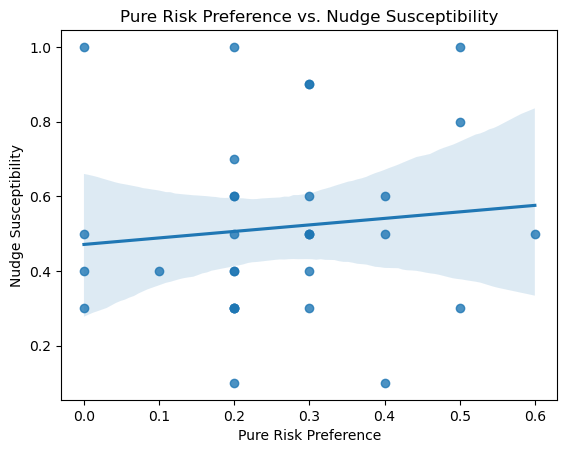

In [27]:
sns.regplot(
    data=risk_df,
    x="pure_risk_preference",
    y="nudge_susceptibility"
)
plt.title('Pure Risk Preference vs. Nudge Susceptibility')
plt.xlabel('Pure Risk Preference')
plt.ylabel('Nudge Susceptibility')

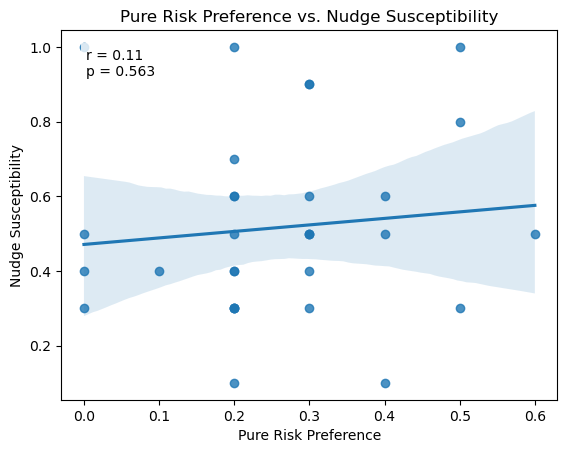

In [28]:
sns.regplot(
    data=risk_df,
    x="pure_risk_preference",
    y="nudge_susceptibility"
)

r, p = pearsonr(risk_df["pure_risk_preference"], risk_df["nudge_susceptibility"])
p_text = f"{p:.3f}" if p >= 0.001 else "< 0.001"

plt.text(
    0.05, 0.95,
    f"r = {r:.2f}\np = {p_text}",
    transform=plt.gca().transAxes,
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

plt.title('Pure Risk Preference vs. Nudge Susceptibility')
plt.xlabel('Pure Risk Preference')
plt.ylabel('Nudge Susceptibility')
plt.savefig('Pure Risk Preference vs. Nudge Susceptibility.png', dpi=300, bbox_inches='tight')
plt.show()

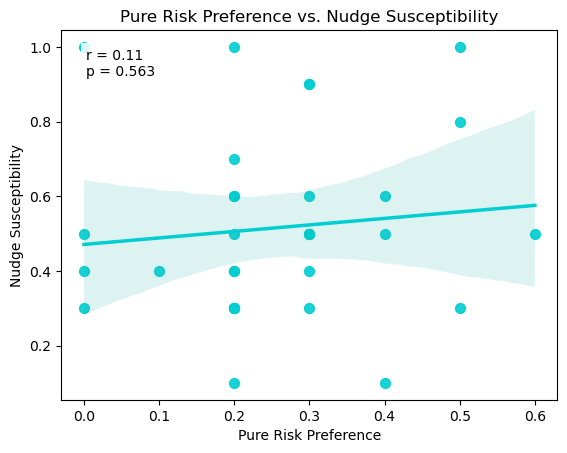

In [29]:
#fig, ax = plt.subplots(figsize=(8, 6))
fig, ax = plt.subplots()

main_green = "darkturquoise"
shade_green = "#20B2AA"

sns.regplot(
    data=risk_df,
    x="pure_risk_preference",
    y="nudge_susceptibility",
    ax=ax,
    scatter_kws={"s": 50, "alpha": 0.9, "color": main_green},
    line_kws={"color": main_green, "linewidth": 2.5}
)

for coll in ax.collections:
    if isinstance(coll, mc.PolyCollection): # we need to use polycollection to recolor the CI band
        coll.set_facecolor(mcolors.to_rgba(shade_green, alpha=0.35))
        coll.set_edgecolor("none")

r, p = pearsonr(risk_df["pure_risk_preference"], risk_df["nudge_susceptibility"])
p_text = f"{p:.3f}" if p >= 0.001 else "< 0.001"

ax.text(
    0.05, 0.95,
    f"r = {r:.2f}\np = {p_text}",
    transform=ax.transAxes,
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="none")
)

ax.set_title("Pure Risk Preference vs. Nudge Susceptibility")
ax.set_xlabel("Pure Risk Preference")
ax.set_ylabel("Nudge Susceptibility")

plt.savefig("Pure Risk Preference vs. Nudge Susceptibility.png", dpi=300, bbox_inches="tight")
plt.show()

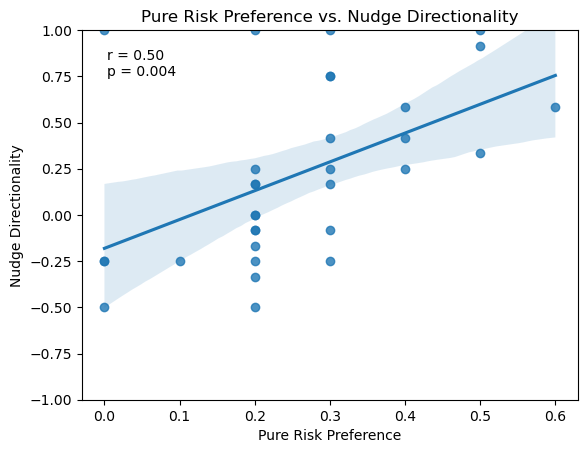

In [30]:
sns.regplot(
    data=risk_df,
    x="pure_risk_preference",
    y="nudge_directionality"
)

r, p = pearsonr(risk_df["pure_risk_preference"], risk_df["nudge_directionality"])
p_text = f"{p:.3f}" if p >= 0.001 else "< 0.001"

plt.text(
    0.05, 0.95,
    f"r = {r:.2f}\np = {p_text}",
    transform=plt.gca().transAxes,
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

plt.title('Pure Risk Preference vs. Nudge Directionality')
plt.xlabel('Pure Risk Preference')
plt.ylabel('Nudge Directionality')
plt.ylim([-1,1])
plt.savefig('Pure Risk Preference vs. Nudge Directionality.png', dpi=300, bbox_inches='tight')
plt.show()

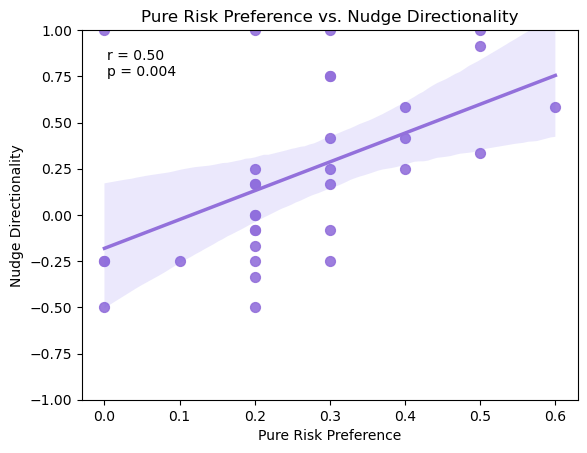

In [31]:
fig, ax = plt.subplots()

main_purple = "mediumpurple"
shade_purple = "mediumslateblue"

sns.regplot(
    data=risk_df,
    x="pure_risk_preference",
    y="nudge_directionality",
    ax=ax,
    scatter_kws={"s": 50, "alpha": 0.9, "color": main_purple},
    line_kws={"color": main_purple, "linewidth": 2.5}
)

for coll in ax.collections: # this recolors just the confidence band
    if isinstance(coll, mc.PolyCollection):
        coll.set_facecolor(mcolors.to_rgba(shade_purple, alpha=0.35))
        coll.set_edgecolor("none")

r, p = pearsonr(risk_df["pure_risk_preference"], risk_df["nudge_directionality"])
p_text = f"{p:.3f}" if p >= 0.001 else "< 0.001"

ax.text(
    0.05, 0.95,
    f"r = {r:.2f}\np = {p_text}",
    transform=ax.transAxes,
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

ax.set_title("Pure Risk Preference vs. Nudge Directionality")
ax.set_xlabel("Pure Risk Preference")
ax.set_ylabel("Nudge Directionality")
ax.set_ylim([-1, 1])

plt.savefig("Pure Risk Preference vs. Nudge Directionality.png", dpi=300, bbox_inches="tight")
plt.show()

(-1.0, 1.0)

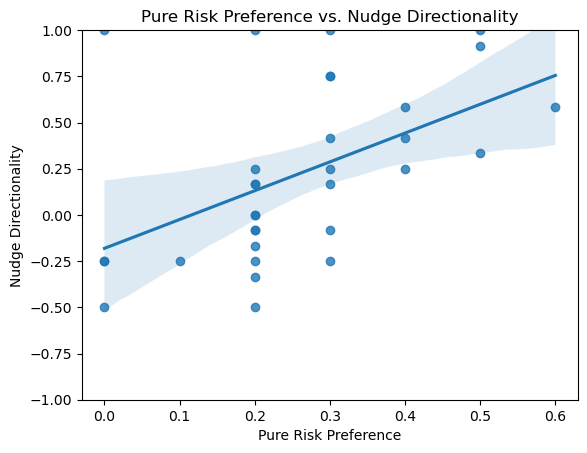

In [32]:
sns.regplot(
    data=risk_df,
    x="pure_risk_preference",
    y="nudge_directionality"
)
plt.title('Pure Risk Preference vs. Nudge Directionality')
plt.xlabel('Pure Risk Preference')
plt.ylabel('Nudge Directionality')
plt.ylim([-1,1])

n participants: 32
risky nudge items found: 6 safe nudge items found: 3
NaNs: {'accept_to_risky': 0, 'accept_to_safe': 0}


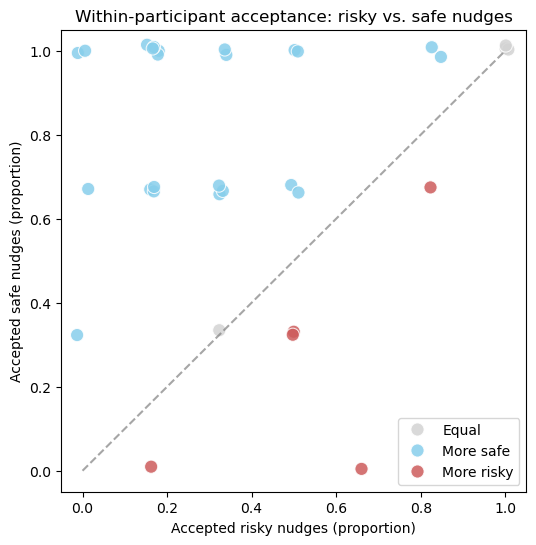

In [52]:
# rebuild lists of nudge questions by direction
valid_nudges = questions_df[
    questions_df.index.str.contains("nudge") &
    questions_df["risky_choice"].isin(["A", "B"])
]

to_risky = valid_nudges[valid_nudges["nudge_direction"] == "to_risky"].index.to_list()
to_safe  = valid_nudges[valid_nudges["nudge_direction"] == "to_safe"].index.to_list()

# map to the participant accept columns that exist in risk_df
risky_cols = [f"{q}_accept" for q in to_risky if f"{q}_accept" in risk_df.columns]
safe_cols  = [f"{q}_accept" for q in to_safe  if f"{q}_accept" in risk_df.columns]

# proportions of participant-level acceptance
risk_df[risky_cols + safe_cols] = risk_df[risky_cols + safe_cols].apply(pd.to_numeric, errors="coerce")
risk_df["accept_to_risky"] = risk_df[risky_cols].mean(axis=1)
risk_df["accept_to_safe"]  = risk_df[safe_cols].mean(axis=1)

print("n participants:", len(risk_df))
print("risky nudge items found:", len(risky_cols), "safe nudge items found:", len(safe_cols))
print("NaNs:", risk_df[["accept_to_risky", "accept_to_safe"]].isna().sum().to_dict())

# within-participant scatter where each dot = 1 subject
x = risk_df["accept_to_risky"].to_numpy()
y = risk_df["accept_to_safe"].to_numpy()

mask = ~np.isnan(x) & ~np.isnan(y)
x = x[mask]
y = y[mask]

# tiny jitter so overlaps are visible
xj = x + np.random.uniform(-0.015, 0.015, len(x))
yj = y + np.random.uniform(-0.015, 0.015, len(y))

plot_df = pd.DataFrame({
    "accept_to_risky": xj,
    "accept_to_safe": yj,
    "bias": np.where(y > x, "More safe", np.where(y < x, "More risky", "Equal"))
})

palette = {"More risky": "indianred", "More safe": "skyblue", "Equal": "lightgray"}

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "--", color="gray", alpha=0.7)

sns.scatterplot(
    data=plot_df,
    x="accept_to_risky",
    y="accept_to_safe",
    hue="bias",
    palette=palette,
    s=90,
    alpha=0.85
)

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel("Accepted risky nudges (proportion)")
plt.ylabel("Accepted safe nudges (proportion)")
plt.title("Within-participant acceptance: risky vs. safe nudges")
plt.legend(title="")
plt.show()

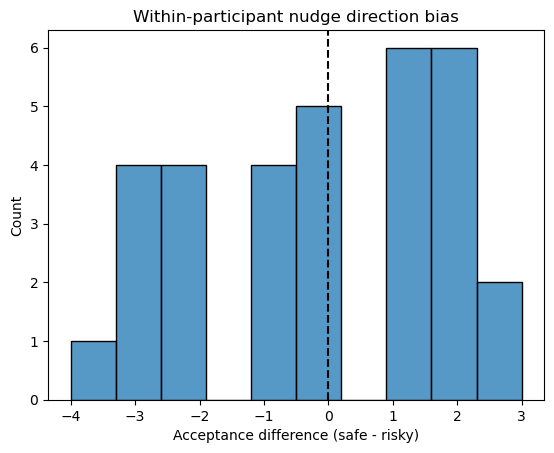

In [48]:
# within-participant difference (safe - risky)

diff = risk_df["accept_to_safe"] - risk_df["accept_to_risky"]

sns.histplot(diff, bins=10, kde=False)
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Acceptance difference (safe - risky)")
plt.ylabel("Count")
plt.title("Within-participant nudge direction bias")
plt.show()

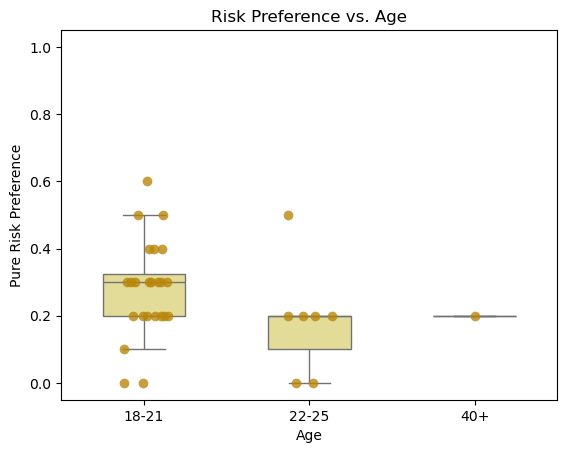

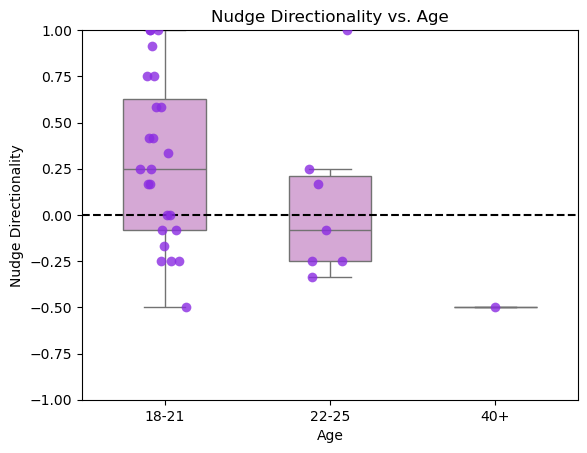

In [75]:
# risk preference vs age group
fig, ax = plt.subplots()

sns.boxplot(
    data=plot_df,
    x="age",
    y="pure_risk_preference",
    order=age_order,
    color="khaki",
    width=0.5,
    fliersize=0,
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x="age",
    y="pure_risk_preference",
    order=age_order,
    color="darkgoldenrod",
    jitter=0.15,
    alpha=0.8,
    size=7,
    ax=ax
)

ax.set_title("Risk Preference vs. Age")
ax.set_xlabel("Age")
ax.set_ylabel("Pure Risk Preference")
ax.set_ylim(-0.05, 1.05)

plt.savefig("Risk Preference vs Age Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()


# nudge directionality vs age group
fig, ax = plt.subplots()

sns.boxplot(
    data=plot_df,
    x="age",
    y="nudge_directionality",
    order=age_order,
    color="plum",
    width=0.5,
    fliersize=0,
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x="age",
    y="nudge_directionality",
    order=age_order,
    color="blueviolet",
    jitter=0.15,
    alpha=0.8,
    size=7,
    ax=ax
)

ax.axhline(0, color="black", linestyle="--")
ax.set_title("Nudge Directionality vs. Age")
ax.set_xlabel("Age")
ax.set_ylabel("Nudge Directionality")
ax.set_ylim(-1, 1)

plt.savefig("Nudge Directionality vs Age Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

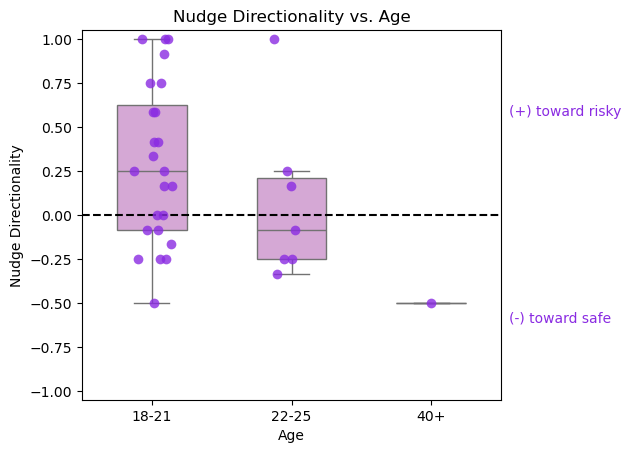

In [77]:
# nudge directionality vs age group
fig, ax = plt.subplots()

sns.boxplot(
    data=plot_df,
    x="age",
    y="nudge_directionality",
    order=age_order,
    color="plum",
    width=0.5,
    fliersize=0,
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x="age",
    y="nudge_directionality",
    order=age_order,
    color="blueviolet",
    jitter=0.15,
    alpha=0.8,
    size=7,
    ax=ax
)

ax.axhline(0, color="black", linestyle="--")
ax.set_title("Nudge Directionality vs. Age")
ax.set_xlabel("Age")
ax.set_ylabel("Nudge Directionality")
ax.set_ylim(-1.05, 1.05)

# change these if your sign convention is flipped
pos_label = "(+) toward risky"
neg_label = "(-) toward safe"

# make room on the right for the labels
fig.subplots_adjust(right=0.78)

# add labels outside the plotting area so they don't cover the data
ax.text(
    1.02, 0.78, pos_label,
    transform=ax.transAxes,
    ha="left", va="center",
    color="blueviolet",
    fontsize=10
)

ax.text(
    1.02, 0.22, neg_label,
    transform=ax.transAxes,
    ha="left", va="center",
    color="blueviolet",
    fontsize=10
)

plt.savefig("Nudge Directionality vs Age Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

['<$50,000', '$50,000-100,000', '$100,000-200,000', '$250,000+', 'Decline']


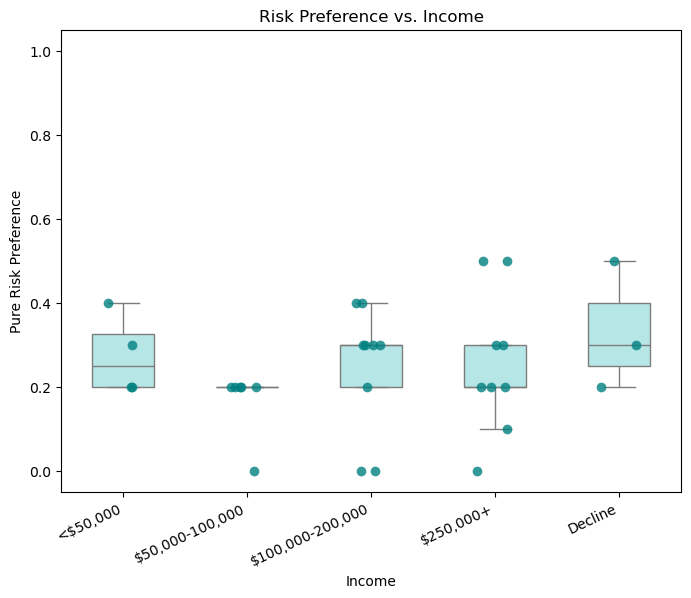

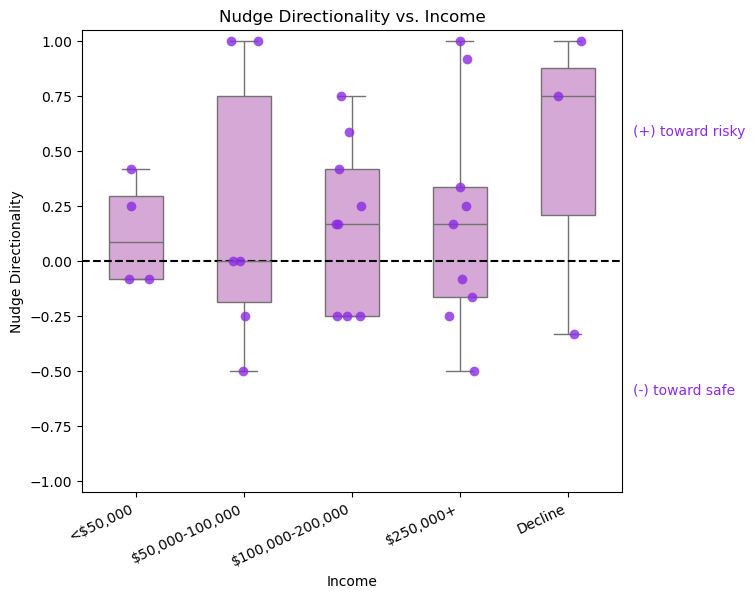

In [82]:
# merge income into risk_df for plotting
plot_df = risk_df[["participant", "pure_risk_preference", "nudge_directionality"]].merge(
    data[["participant", "income"]],
    on="participant",
    how="left"
)

plot_df = plot_df.dropna(subset=["income", "pure_risk_preference", "nudge_directionality"])

# sort income brackets by their lower bound
def income_sort_key(x):
    x = str(x)

    if "prefer" in x.lower():
        return 999999999

    nums = re.findall(r"\d[\d,]*", x)
    if len(nums) > 0:
        return int(nums[0].replace(",", ""))

    return 999999999

income_order = sorted(plot_df["income"].dropna().unique(), key=income_sort_key)
print(income_order)


# risk preference vs income
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=plot_df,
    x="income",
    y="pure_risk_preference",
    order=income_order,
    color="paleturquoise",
    width=0.5,
    fliersize=0,
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x="income",
    y="pure_risk_preference",
    order=income_order,
    color="teal",
    jitter=0.15,
    alpha=0.8,
    size=7,
    ax=ax
)

ax.set_title("Risk Preference vs. Income")
ax.set_xlabel("Income")
ax.set_ylabel("Pure Risk Preference")
ax.set_ylim(-0.05, 1.05)
plt.xticks(rotation=25, ha="right")

plt.savefig("Risk Preference vs Income Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()


# nudge directionality vs income
fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=plot_df,
    x="income",
    y="nudge_directionality",
    order=income_order,
    color="plum",
    width=0.5,
    fliersize=0,
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x="income",
    y="nudge_directionality",
    order=income_order,
    color="blueviolet",
    jitter=0.15,
    alpha=0.8,
    size=7,
    ax=ax
)

ax.axhline(0, color="black", linestyle="--")
ax.set_title("Nudge Directionality vs. Income")
ax.set_xlabel("Income")
ax.set_ylabel("Nudge Directionality")
ax.set_ylim(-1.05, 1.05)
plt.xticks(rotation=25, ha="right")

# labels outside plot so they don't cover the data
fig.subplots_adjust(right=0.8)

ax.text(
    1.02, 0.78, "(+) toward risky",
    transform=ax.transAxes,
    ha="left", va="center",
    color="blueviolet", fontsize=10
)

ax.text(
    1.02, 0.22, "(-) toward safe",
    transform=ax.transAxes,
    ha="left", va="center",
    color="blueviolet", fontsize=10
)

plt.savefig("Nudge Directionality vs Income Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

['18-21', '22-25', '40+']


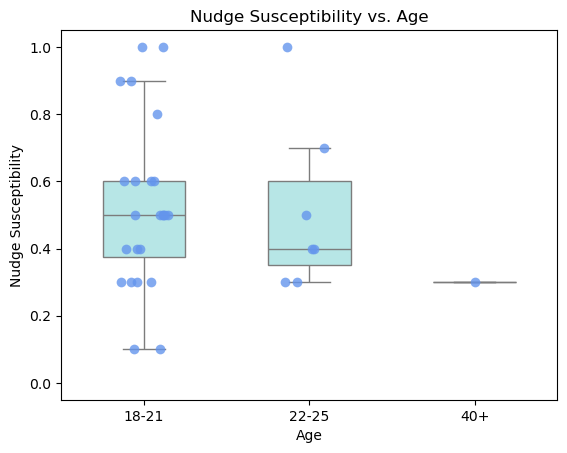

In [88]:
# nudge susceptibility vs age
plot_df = risk_df[["participant", "nudge_susceptibility"]].merge(
    data[["participant", "age"]],
    on="participant",
    how="left"
)

plot_df = plot_df.dropna(subset=["age", "nudge_susceptibility"])

def age_sort_key(x):
    x = str(x)
    if "-" in x:
        return int(x.split("-")[0])
    if "+" in x:
        return int(x.replace("+", ""))
    return 999

age_order = sorted(plot_df["age"].dropna().unique(), key=age_sort_key)
print(age_order)

fig, ax = plt.subplots()

sns.boxplot(
    data=plot_df,
    x="age",
    y="nudge_susceptibility",
    order=age_order,
    color="paleturquoise",
    width=0.5,
    fliersize=0,
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x="age",
    y="nudge_susceptibility",
    order=age_order,
    color="cornflowerblue",
    jitter=0.15,
    alpha=0.8,
    size=7,
    ax=ax
)

ax.set_title("Nudge Susceptibility vs. Age")
ax.set_xlabel("Age")
ax.set_ylabel("Nudge Susceptibility")
ax.set_ylim(-0.05, 1.05)

plt.savefig("Nudge Susceptibility vs Age Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

['<$50,000', '$50,000-100,000', '$100,000-200,000', '$250,000+', 'Decline']


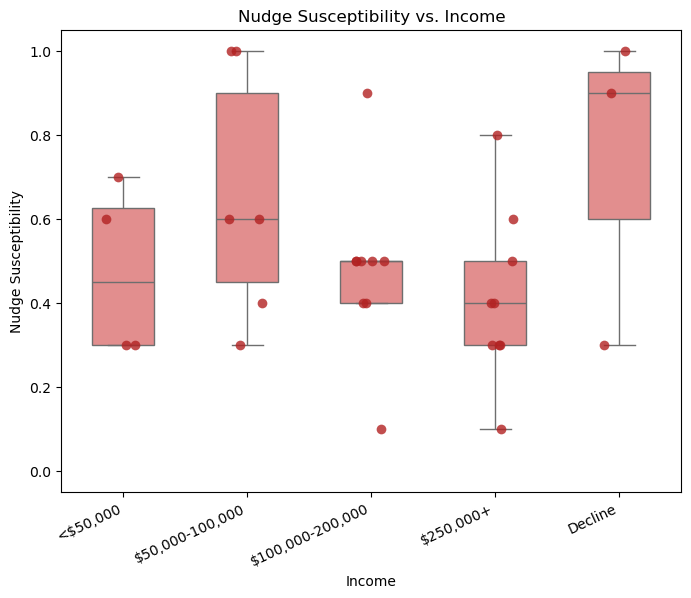

In [84]:
# nudge susceptibility vs income
plot_df = risk_df[["participant", "nudge_susceptibility"]].merge(
    data[["participant", "income"]],
    on="participant",
    how="left"
)

plot_df = plot_df.dropna(subset=["income", "nudge_susceptibility"])

def income_sort_key(x):
    x = str(x)

    if "prefer" in x.lower():
        return 999999999

    nums = re.findall(r"\d[\d,]*", x)
    if len(nums) > 0:
        return int(nums[0].replace(",", ""))

    return 999999999

income_order = sorted(plot_df["income"].dropna().unique(), key=income_sort_key)
print(income_order)

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(
    data=plot_df,
    x="income",
    y="nudge_susceptibility",
    order=income_order,
    color="lightcoral",
    width=0.5,
    fliersize=0,
    ax=ax
)

sns.stripplot(
    data=plot_df,
    x="income",
    y="nudge_susceptibility",
    order=income_order,
    color="firebrick",
    jitter=0.15,
    alpha=0.8,
    size=7,
    ax=ax
)

ax.set_title("Nudge Susceptibility vs. Income")
ax.set_xlabel("Income")
ax.set_ylabel("Nudge Susceptibility")
ax.set_ylim(-0.05, 1.05)
plt.xticks(rotation=25, ha="right")

plt.savefig("Nudge Susceptibility vs Income Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

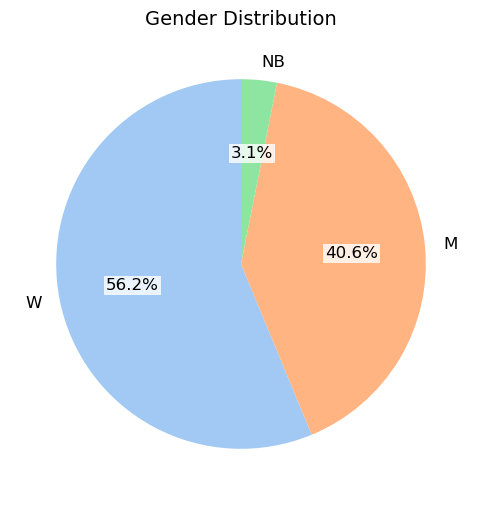

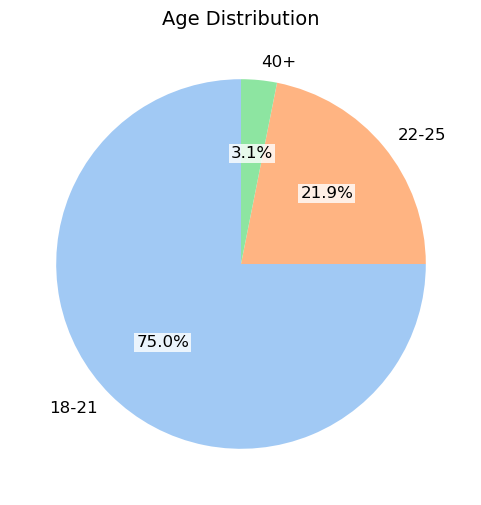

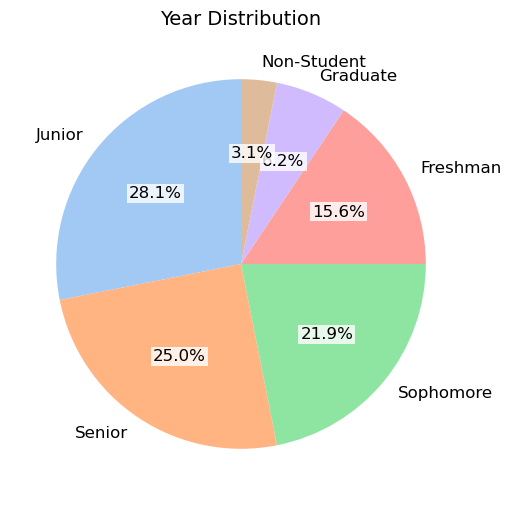

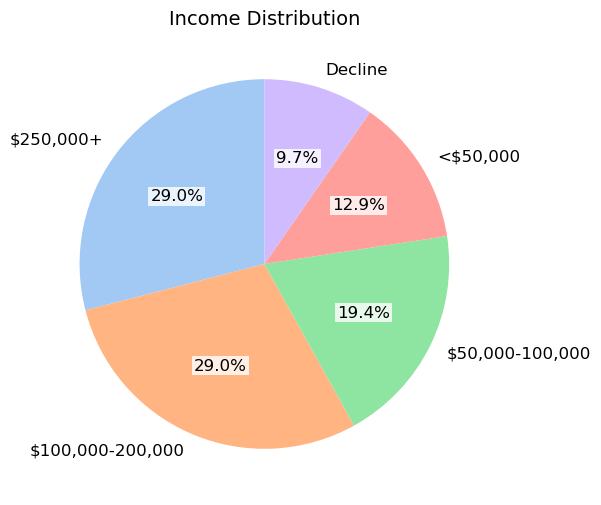

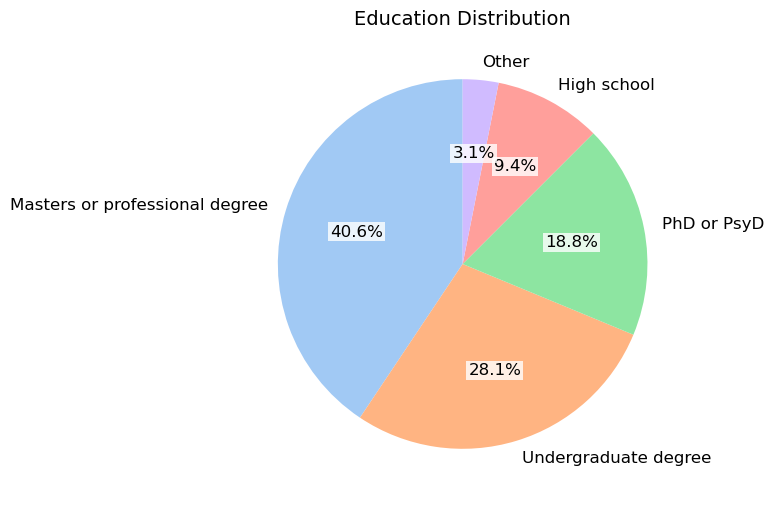

In [90]:
# function to create pie charts for all the demographics questions
def plot_demo_pie(col, title, filename):
    counts = data[col].dropna().value_counts()

    plt.figure(figsize=(6, 6))
    wedges, texts, autotexts = plt.pie(
        counts.values,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("pastel", len(counts)),
        textprops={"fontsize": 12}
    )

    for autotext in autotexts:
        autotext.set_fontsize(12)
        autotext.set_bbox(dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))

    plt.title(title, fontsize=14)
    plt.ylabel("")

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# separate demographic pie charts
plot_demo_pie("gender", "Gender Distribution", "Gender Distribution Pie Chart.png")
plot_demo_pie("age", "Age Distribution", "Age Distribution Pie Chart.png")
plot_demo_pie("year", "Year Distribution", "Year Distribution Pie Chart.png")
plot_demo_pie("income", "Income Distribution", "Income Distribution Pie Chart.png")
plot_demo_pie("parent_edu", "Education Distribution", "Education Distribution Pie Chart.png")

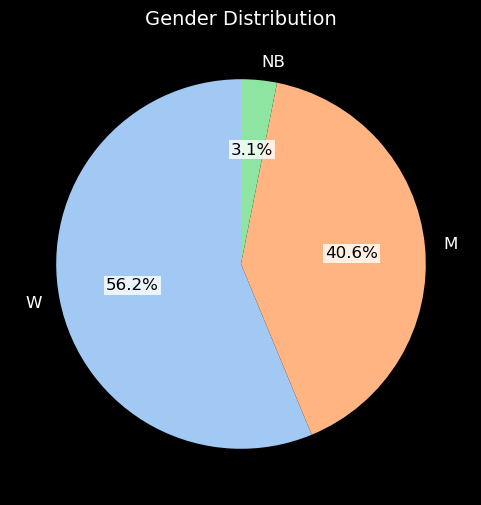

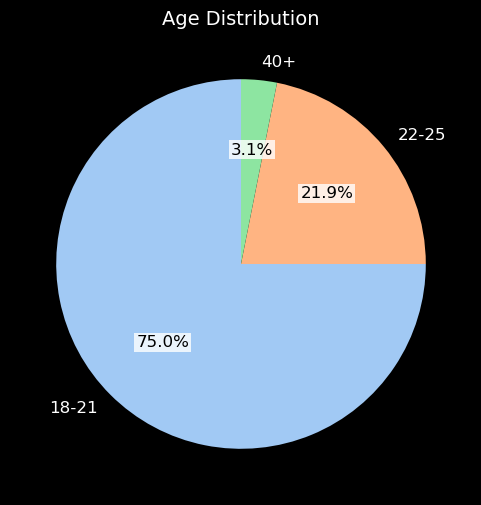

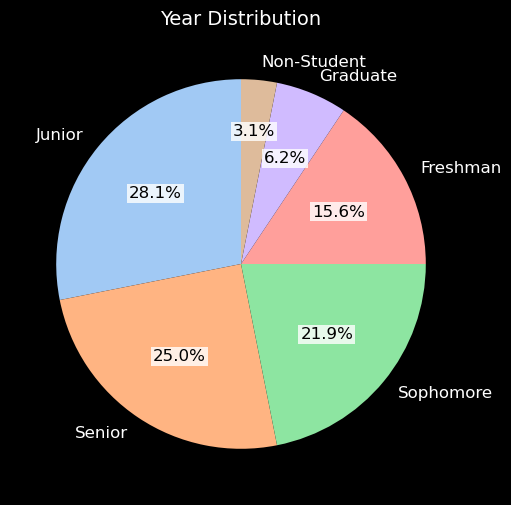

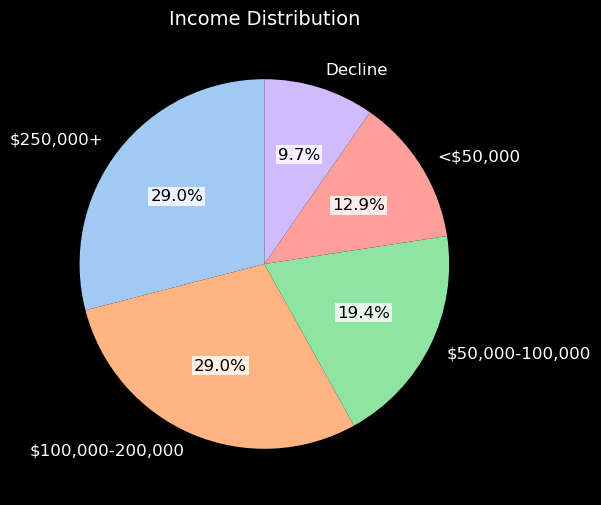

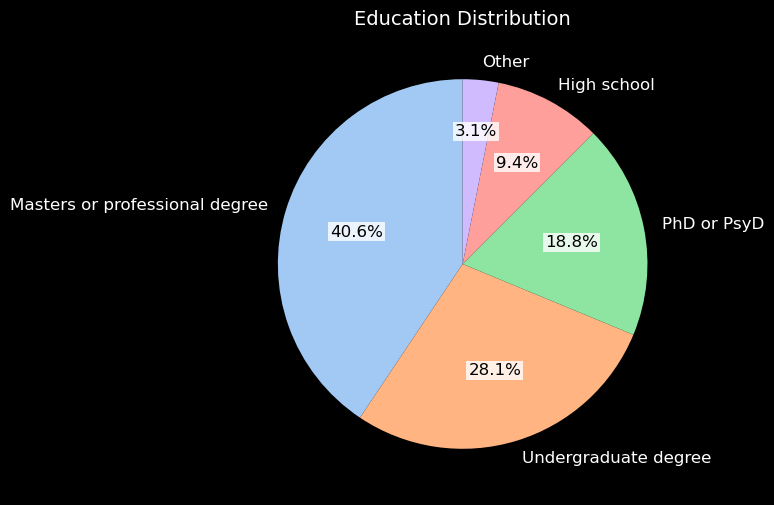

In [92]:
# simple helper function for demographic pie charts
def plot_demo_pie(col, title, filename):
    counts = data[col].dropna().value_counts()

    fig, ax = plt.subplots(figsize=(6, 6), facecolor="black")
    ax.set_facecolor("black")

    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("pastel", len(counts)),
        textprops={"fontsize": 12, "color": "white"}
    )

    # outer text labels
    for text in texts:
        text.set_color("white")
        text.set_fontsize(12)

    total = counts.sum()

    # percentage labels inside pie
    small_count = 0
    for wedge, autotext, value in zip(wedges, autotexts, counts.values):
        pct = 100 * value / total

        autotext.set_fontsize(12)
        autotext.set_color("black")
        autotext.set_bbox(dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))

        # move small-slice percentage labels a bit so they don't overlap
        if pct < 12:
            angle = np.deg2rad((wedge.theta1 + wedge.theta2) / 2)

            # alternate radius slightly for neighboring small slices
            r = 0.62 + 0.10 * (small_count % 2)

            x = r * np.cos(angle)
            y = r * np.sin(angle)

            autotext.set_position((x, y))
            small_count += 1

    ax.set_title(title, fontsize=14, color="white")
    ax.set_ylabel("")

    plt.savefig(filename, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.show()


# separate demographic pie charts
plot_demo_pie("gender", "Gender Distribution", "Gender Distribution Pie Chart.png")
plot_demo_pie("age", "Age Distribution", "Age Distribution Pie Chart.png")
plot_demo_pie("year", "Year Distribution", "Year Distribution Pie Chart.png")
plot_demo_pie("income", "Income Distribution", "Income Distribution Pie Chart.png")
plot_demo_pie("parent_edu", "Education Distribution", "Education Distribution Pie Chart.png")

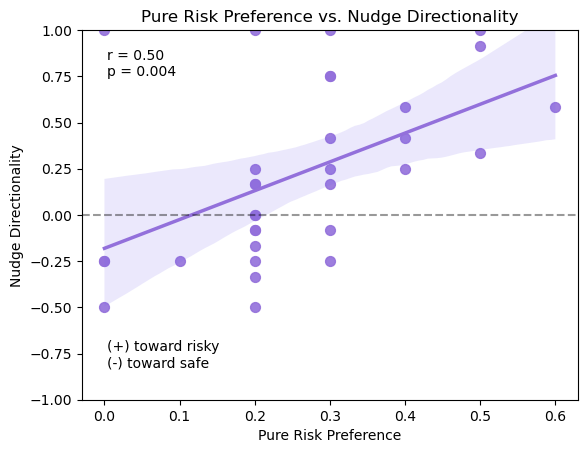

In [94]:
fig, ax = plt.subplots()

main_purple = "mediumpurple"
shade_purple = "mediumslateblue"

sns.regplot(
    data=risk_df,
    x="pure_risk_preference",
    y="nudge_directionality",
    ax=ax,
    scatter_kws={"s": 50, "alpha": 0.9, "color": main_purple},
    line_kws={"color": main_purple, "linewidth": 2.5}
)

for coll in ax.collections:  # this recolors just the confidence band
    if isinstance(coll, mc.PolyCollection):
        coll.set_facecolor(mcolors.to_rgba(shade_purple, alpha=0.35))
        coll.set_edgecolor("none")

r, p = pearsonr(risk_df["pure_risk_preference"], risk_df["nudge_directionality"])
p_text = f"{p:.3f}" if p >= 0.001 else "< 0.001"

ax.text(
    0.05, 0.95,
    f"r = {r:.2f}\np = {p_text}",
    transform=ax.transAxes,
    ha="left", va="top",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

# horizontal dashed line at zero
ax.axhline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.4)

# direction labels in bottom-left corner
ax.text(
    0.05, 0.08,
    "(+) toward risky\n(-) toward safe",
    transform=ax.transAxes,
    ha="left", va="bottom",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
)

ax.set_title("Pure Risk Preference vs. Nudge Directionality")
ax.set_xlabel("Pure Risk Preference")
ax.set_ylabel("Nudge Directionality")
ax.set_ylim([-1, 1])

plt.savefig("Pure Risk Preference vs. Nudge Directionality.png", dpi=300, bbox_inches="tight")
plt.show()